# Middle East Oil and Economic Analysis
**Group D - Data Science Project**
### 1. Pre-Processing & Exploratory Data Analysis (EDA)
In this section, we load the dataset, perform basic integrity checks, clean the data by removing missing values and unnecessary string columns, and visualize the economic trends.

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("Middle_East_Economic_Data_1990_2024_with_Oil.csv")


print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values Check (Before Cleaning):")
print(df.isnull().sum())

First 5 rows of the dataset:


,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel
0,Bahrain,BHR,1990,101.627082,1.907789,4.809511e+09,4.437997,9342.538914,83.201723,0.929335,72.587,NaN,23.0
1,Bahrain,BHR,1991,74.757141,11.800826,5.248911e+09,11.229998,10434.132396,84.110656,0.764420,72.668,1.047,20.0
2,Bahrain,BHR,1992,74.210844,16.078853,5.402232e+09,6.689998,10460.158322,85.081054,-0.172414,72.785,0.968,18.0
3,Bahrain,BHR,1993,73.764609,-4.650769,5.913001e+09,12.870007,11151.871496,70.998436,2.538860,72.939,0.882,19.0
4,Bahrain,BHR,1994,71.406483,3.289479,6.330628e+09,-0.250001,11629.359522,65.066988,0.816911,73.134,1.007,25.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               455 non-null    object 
 1   Country_Code                          455 non-null    object 
 2   Year                                  455 non-null    int64  
 3   Exports_pct_GDP                       429 non-null    float64
 4   FDI_net_inflows_pct_GDP               446 non-null    float64
 5   GDP_current_USD                       448 non-null    float64
 6   GDP_growth_annual_pct                 447 non-null    float64
 7   GDP_per_capita_current_USD            448 non-null    float64
 8   Imports_pct_GDP                       429 non-null    float64
 9   Inflation_consumer_prices_annual_pct  395 non-null    float64
 10  Life_expectancy_years                 442 non-null    float64
 1

### 2. Data Cleaning
We need to remove non-numeric columns (like Country names) because regression models require numerical input. We also drop missing values to ensure our model doesn't crash.

In [5]:
df_cleaned = df.drop(['Country', 'Country_Code'], axis=1)

df_cleaned['Year'] = df_cleaned['Year'].astype(int)

df_cleaned = df_cleaned.fillna(df_cleaned.mean(numeric_only=True))

df_cleaned['Oil_Price_Lag1'] = df_cleaned['Brent_Oil_Price_USD_per_barrel'].shift(1)

df_cleaned = df_cleaned.dropna()

print(f"Data shape after cleaning: {df_cleaned.shape}")

Data shape after cleaning: (454, 12)


### 3. Exploratory Data Analysis: Oil Price Trend
To prevent messy, overlapping lines, we group the data by year and calculate the average global oil price for that year.

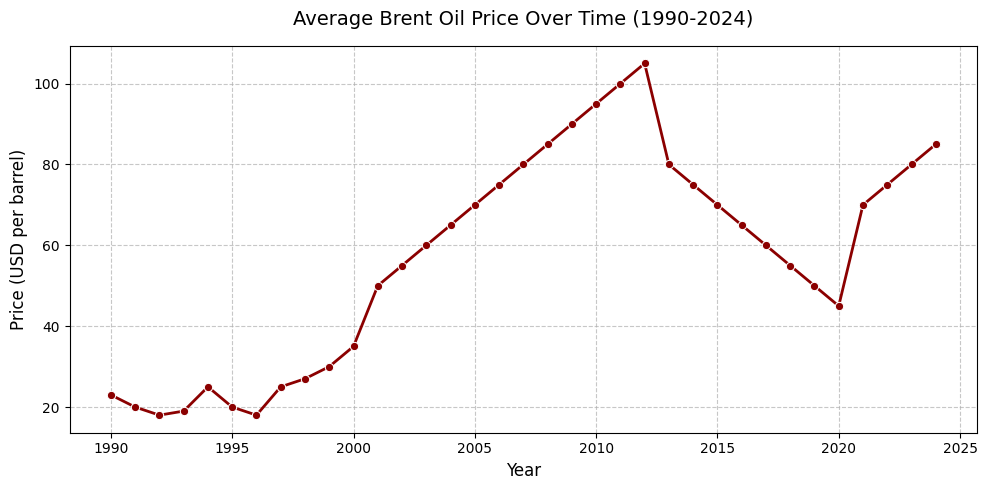

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


yearly_trend = df_cleaned.groupby('Year').mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_trend, x='Year', y='Brent_Oil_Price_USD_per_barrel', marker='o', color='darkred', linewidth=2)
plt.title("Average Brent Oil Price Over Time (1990-2024)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Price (USD per barrel)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4. Exploratory Data Analysis: Correlation Heatmap
This heatmap shows us the mathematical relationship between our economic indicators and the oil price.

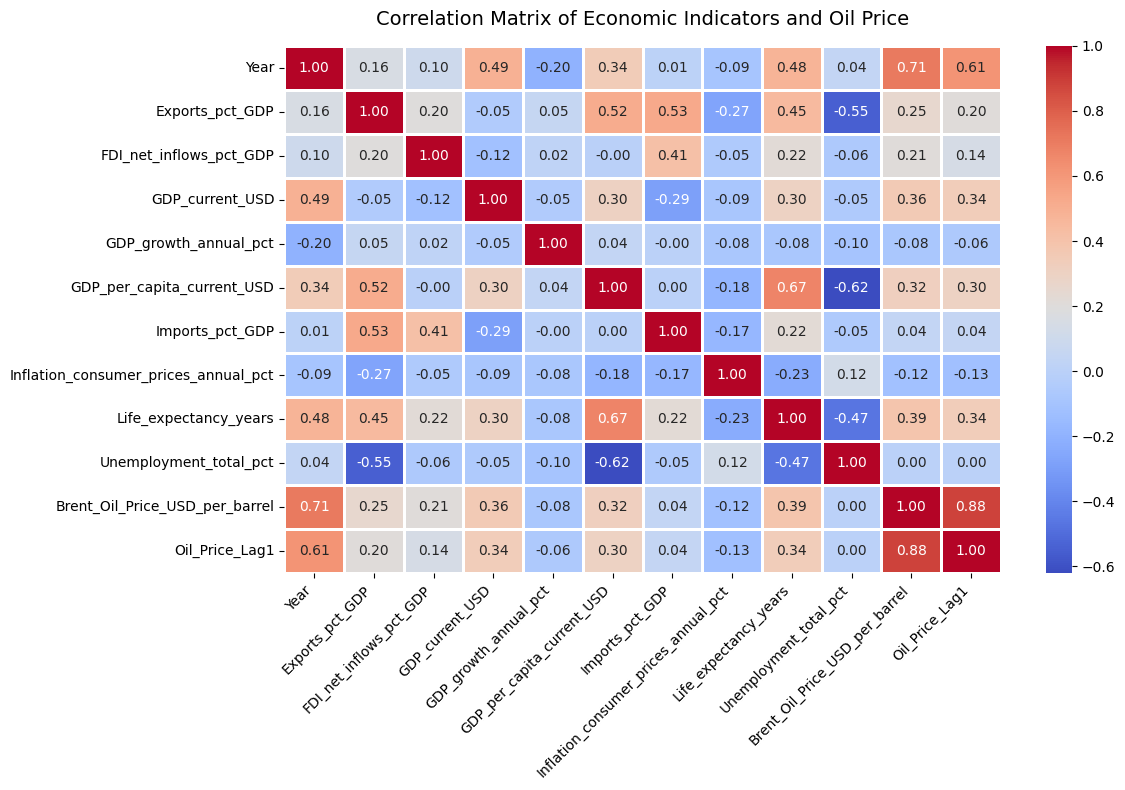

In [7]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, annot_kws={"size": 10})
plt.title("Correlation Matrix of Economic Indicators and Oil Price", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Feature Selection & Data Splitting
We select the specific features mentioned in our proposal and split the data: 80% for training the model, and 20% for testing it on unseen data.

In [8]:

from sklearn.model_selection import train_test_split

features = [
    'GDP_growth_annual_pct', 
    'Inflation_consumer_prices_annual_pct', 
    'Exports_pct_GDP', 
    'Unemployment_total_pct',
    'Oil_Price_Lag1'         
]

X = df_cleaned[features]
y = df_cleaned['Brent_Oil_Price_USD_per_barrel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (363, 5)
Testing data shape: (91, 5)


### 6. Baseline Model: Linear Regression
We start with a simple linear regression to establish a baseline performance metric.

In [9]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Linear Regression model trained.")

Linear Regression model trained.


### 7. Advanced Model 1: Random Forest
Using a Random Forest Regressor and applying 5-Fold Cross-Validation to test model stability across different data splits.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print("Baseline Random Forest")
print("CV R² Scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

Baseline Random Forest
CV R² Scores: [0.93755865 0.90833236 0.93386418 0.74501577 0.96892178]
Average CV R²: 0.8987385480956807


### 8. Post-Processing: Pruning & Hyperparameter Tuning
To meet the post-processing requirement, we use Grid Search to "prune" our Random Forest. By restricting tree depth and split criteria, we filter out noisy rules and prevent overfitting.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],  
    'min_samples_split': [2, 5, 10] 
}

grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, 
                           n_jobs=-1, 
                           scoring='r2')

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

print(f"Best Pruned Parameters found: {grid_search.best_params_}")

Best Pruned Parameters found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


### 9. Advanced Model 2: XGBoost
We implement XGBoost (Extreme Gradient Boosting), an industry-standard tree-based algorithm, to see if it can outperform our Pruned Random Forest.

In [12]:

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error

xgb_base = xgb.XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

param_dist = {
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 100],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)
xgb_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

y_pred_xgb = xgb_model.predict(X_test)


y_pred_clipped = np.clip(y_pred_xgb, 0, None)

max_threshold = y_pred_clipped.mean() + 3 * y_pred_clipped.std()
y_pred_final = np.where(y_pred_clipped > max_threshold, max_threshold, y_pred_clipped)

print("\n--- Model Performance ---")
print("Before Post-processing:")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

print("\nAfter Post-processing (Clipping + Cap):")
print("R2 Score:", r2_score(y_test, y_pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))

residuals = y_test - y_pred_final
print("\nResidual Stats:")
print("Mean Residual:", np.mean(residuals))
print("Std Residual:", np.std(residuals))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

--- Model Performance ---
Before Post-processing:
R2 Score: 0.9391480170284424
RMSE: 6.7219048321339665

After Post-processing (Clipping + Cap):
R2 Score: 0.9391480170284424
RMSE: 6.7219048321339665

Residual Stats:
Mean Residual: -0.46955745822780737
Std Residual: 6.705484349820571


### 10. Evaluation Metrics
We compare all four models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² Score. *Note: Since we removed the 'Year' column, R² scores will reflect the realistic difficulty of predicting a global commodity using local indicators.*

In [13]:

from sklearn.metrics import mean_absolute_error

def evaluate_and_print(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name}:")
    print(f"  - MAE:  {mae:.2f}")
    print(f"  - RMSE: {rmse:.2f}")
    print(f"  - R²:   {r2:.4f}\n")
    return mae, r2

print("--- EVALUATION METRICS ---\n")
mae_lr, r2_lr = evaluate_and_print("1. Linear Regression", y_test, y_pred_lr)
mae_rf, r2_rf = evaluate_and_print("2. Random Forest (Default)", y_test, y_pred_best_rf)
mae_best, r2_best = evaluate_and_print("3. Random Forest (Pruned)", y_test, y_pred_best_rf)
mae_xgb, r2_xgb = evaluate_and_print("4. XGBoost", y_test, y_pred_final)

--- EVALUATION METRICS ---

1. Linear Regression:
  - MAE:  7.87
  - RMSE: 12.70
  - R²:   0.7828

2. Random Forest (Default):
  - MAE:  4.91
  - RMSE: 8.64
  - R²:   0.8996

3. Random Forest (Pruned):
  - MAE:  4.91
  - RMSE: 8.64
  - R²:   0.8996

4. XGBoost:
  - MAE:  4.83
  - RMSE: 6.72
  - R²:   0.9391



### 11. Model Comparison Visualization
A visual representation comparing the accuracy (R²) and error rate (MAE) across all tested models.

/var/folders/w9/2hd_kfs96fl5mnc7fzvf3wnh0000gn/T/ipykernel_69335/1996598619.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_scores, ax=axes[0], palette='Blues_d')
/var/folders/w9/2hd_kfs96fl5mnc7fzvf3wnh0000gn/T/ipykernel_69335/1996598619.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=mae_scores, ax=axes[1], palette='Reds_d')


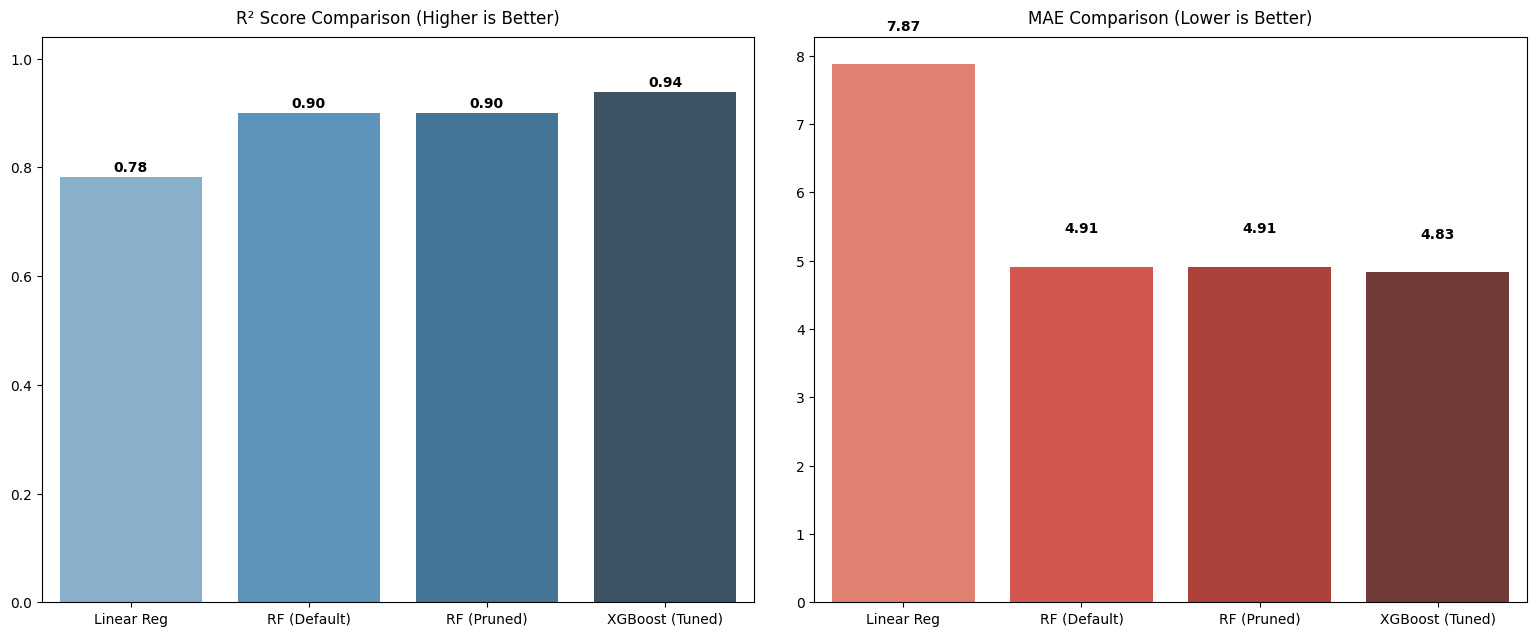

In [14]:
model_names = ['Linear Reg', 'RF (Default)', 'RF (Pruned)', 'XGBoost (Tuned)']
r2_scores = [r2_lr, r2_rf, r2_best, r2_xgb]
mae_scores = [mae_lr, mae_rf, mae_best, mae_xgb]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot R2 Comparison 
sns.barplot(x=model_names, y=r2_scores, ax=axes[0], palette='Blues_d')
axes[0].set_title("R² Score Comparison (Higher is Better)", pad=10)

axes[0].set_ylim(min(0, min(r2_scores) - 0.1), max(max(r2_scores) + 0.1, 0.4)) 
for i, v in enumerate(r2_scores):

    y_offset = 0.01 if v > 0 else -0.05
    axes[0].text(i, v + y_offset, f"{v:.2f}", ha='center', fontweight='bold')

sns.barplot(x=model_names, y=mae_scores, ax=axes[1], palette='Reds_d')
axes[1].set_title("MAE Comparison (Lower is Better)", pad=10)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.5, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()

### 12. Final Outputs: XGBoost Predictions & Feature Importance
Visualizing the accuracy of our XGBoost model, and examining which economic indicator had the highest weight in predicting the oil price.

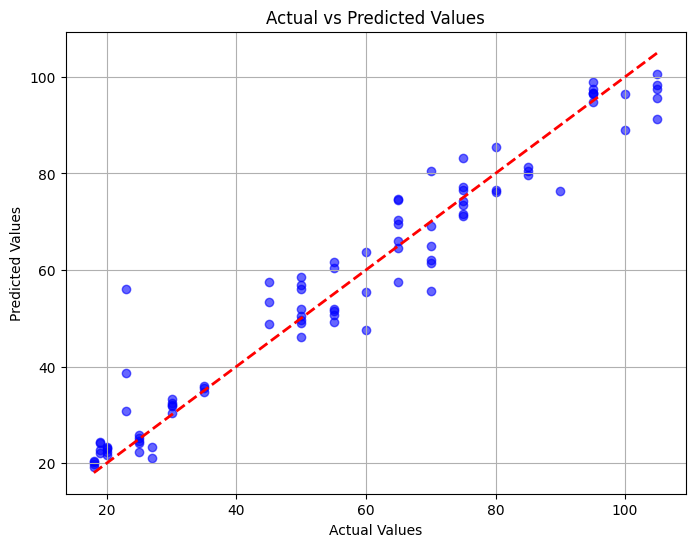

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_final, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()

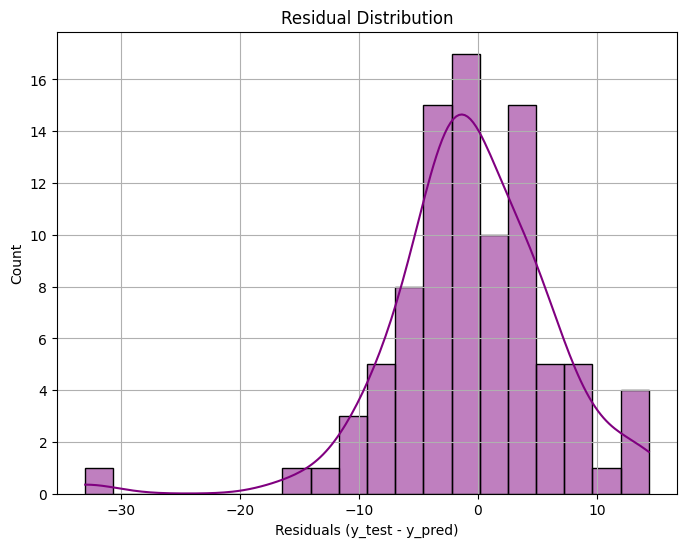

In [16]:

residuals = y_test - y_pred_final

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=20, kde=True, color='purple')
plt.xlabel("Residuals (y_test - y_pred)")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()



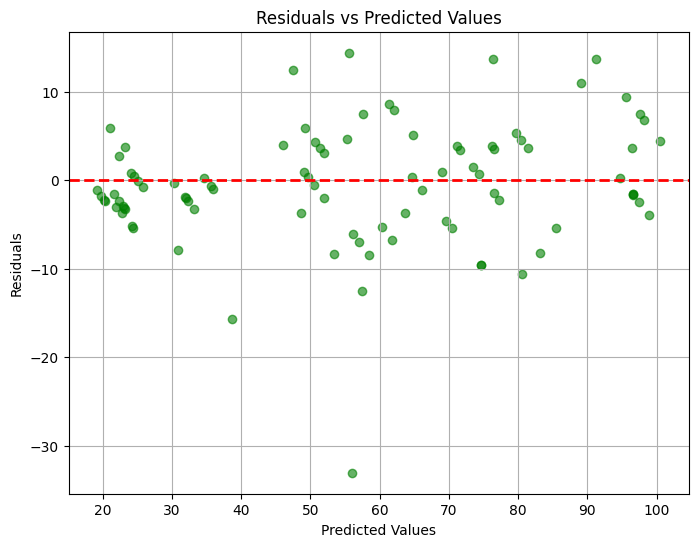

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred_final, residuals, color='green', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)  # zero error line
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.grid(True)
plt.show()

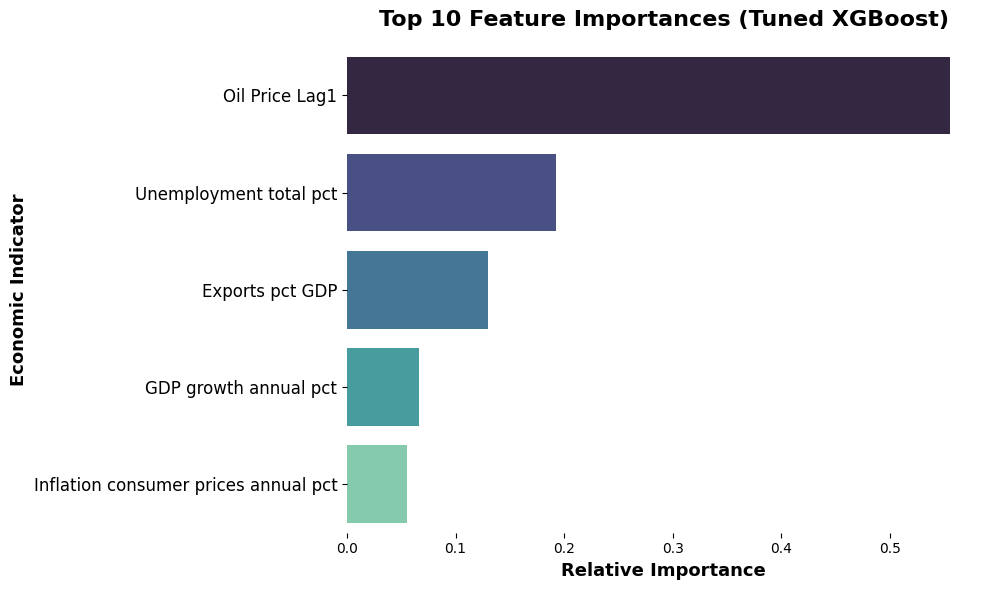

In [18]:

features = X_train.columns 
feature_importances_xgb = xgb_model.feature_importances_

importance_df_xgb = pd.DataFrame({'Feature': features, 'Importance': feature_importances_xgb})
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)

top_10_features = importance_df_xgb.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='mako', hue='Feature', dodge=False, legend=False)

plt.title("Top 10 Feature Importances (Tuned XGBoost)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Relative Importance", fontsize=13, fontweight='bold')
plt.ylabel("Economic Indicator", fontsize=13, fontweight='bold')

clean_labels = [feat.replace('_', ' ') for feat in top_10_features['Feature']]
plt.yticks(ticks=range(len(top_10_features)), labels=clean_labels, fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()